# Ragasa 台风路径追踪（AI 24h/48h）

> 方法：在给定范围 `(lat: 9.5–34.0, lon: 97.0–131.5)` 内逐时（或逐时次）寻找 **最低 MSLP** 的网格点，作为台风中心位置；并与 JMA best track 做线性插值对齐后计算路径误差（km）。

In [1]:
from __future__ import annotations
from pathlib import Path
import re
import numpy as np
import pandas as pd
import xarray as xr

# ----------------------
# Paths & constants
# ----------------------
HERE = Path('.').resolve()
DATA_DIR = Path('./data')
PUBLISH_DIR = Path('./publish')
PUBLISH_DIR.mkdir(exist_ok=True)

AI_ROOT = (Path('../../AI_forecasting_result/Ragasa')).resolve()
ERA5_MSLP_FILE = (Path('../Fig3/data/era5_surface_2025092201-2025092419.nc')).resolve()
BEST_TRACK_FILE = DATA_DIR / 'best_track_Ragasa_JMA.xlsx'

# (lat_min, lat_max, lon_min, lon_max)
TRACK_BBOX = (9.5, 34.0, 97.0, 131.5)

# Plot styles (match Fig2/01_track_forecast.ipynb)
MODEL_STYLES = {
    'era5': {'label': 'ERA5', 'color': '#4c78a8', 'marker': 'x'},
    'pangu': {'label': 'Pangu', 'color': '#f58518', 'marker': 's'},
    'graphcast': {'label': 'GraphCast', 'color': '#54a24b', 'marker': '^'},
    'fengwu': {'label': 'FengWu', 'color': '#e45756', 'marker': 'D'},
    'fuxi': {'label': 'FuXi', 'color': '#72b7b2', 'marker': 'v'},
    'aurora': {'label': 'Aurora', 'color': '#b279a2', 'marker': 'p'},
}

print('AI_ROOT =', AI_ROOT)
print('ERA5_MSLP_FILE exists:', ERA5_MSLP_FILE.exists())
print('BEST_TRACK_FILE exists:', BEST_TRACK_FILE.exists())

AI_ROOT = E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa
ERA5_MSLP_FILE exists: True
BEST_TRACK_FILE exists: True


In [2]:
def load_best_track(file_path: Path) -> pd.DataFrame:
    df = (
        pd.read_excel(file_path)
        .rename(
            columns={
                'Time': 'time',
                'Lat': 'lat_tenths',
                'Lon': 'lon_tenths',
                'Pres': 'pres_hpa',
                'Wind': 'wind_kt',
            }
        )
        .assign(
            time=lambda d: pd.to_datetime(d['time'].astype(str), format='%y%m%d%H'),
            lat=lambda d: d['lat_tenths'] / 10,
            lon=lambda d: d['lon_tenths'] / 10,
        )
        [['time', 'lat', 'lon', 'pres_hpa', 'wind_kt']]
        .sort_values('time')
        .reset_index(drop=True)
    )
    return df

track_best = load_best_track(BEST_TRACK_FILE)
track_best.head()

,time,lat,lon,pres_hpa,wind_kt
0,2025-09-18 18:00:00,15.8,132.2,1000,35
1,2025-09-19 00:00:00,15.6,131.6,998,40
2,2025-09-19 06:00:00,15.7,130.9,994,45
3,2025-09-19 12:00:00,15.9,130.5,992,50
4,2025-09-19 18:00:00,16.2,130.1,990,55


In [3]:
# ----------------------
# Helpers: detect coords/time/MSLP
# ----------------------
def _to_datetime_index(values) -> pd.DatetimeIndex:
    # Robust conversion for np.datetime64 / cftime / python datetime / strings
    if isinstance(values, (pd.DatetimeIndex, pd.Index)):
        return pd.DatetimeIndex(values)
    arr = np.asarray(values)
    if arr.dtype.type is np.datetime64:
        return pd.to_datetime(arr)
    return pd.to_datetime([str(v) for v in arr])


def guess_lat_lon_names(ds: xr.Dataset) -> tuple[str, str]:
    candidates_lat = ['lat', 'latitude', 'Latitude', 'LAT']
    candidates_lon = ['lon', 'longitude', 'Longitude', 'LON']
    lat_name = next((n for n in candidates_lat if n in ds.coords or n in ds.variables), None)
    lon_name = next((n for n in candidates_lon if n in ds.coords or n in ds.variables), None)
    if lat_name is None or lon_name is None:
        raise KeyError(
            f'Cannot find lat/lon in dataset. coords={list(ds.coords)} vars={list(ds.data_vars)}'
        )
    return lat_name, lon_name


def guess_time_name(ds: xr.Dataset) -> str | None:
    for name in ['time', 'valid_time', 'forecast_time', 'datetime']:
        if name in ds.coords:
            return name
        if name in ds.variables and ds[name].ndim >= 1:
            return name
    return None


def guess_mslp_var(ds: xr.Dataset) -> str:
    # Priority 1: name contains msl/mslp/prmsl
    for v in ds.data_vars:
        v_low = v.lower()
        if any(k in v_low for k in ['mslp', 'msl', 'prmsl']):
            return v
    # Priority 2: attributes suggest mean sea level pressure
    for v in ds.data_vars:
        attrs = {k.lower(): str(val).lower() for k, val in ds[v].attrs.items()}
        if 'standard_name' in attrs and 'mean_sea_level' in attrs['standard_name']:
            return v
        if 'long_name' in attrs and ('mean sea level' in attrs['long_name'] or 'msl' in attrs['long_name']):
            return v
        if 'description' in attrs and ('mean sea level' in attrs['description'] or 'msl' in attrs['description']):
            return v
    raise KeyError(f'Cannot guess MSLP variable. data_vars={list(ds.data_vars)}')


def parse_valid_time_from_filename(file_path: Path) -> pd.Timestamp | None:
    # Aurora-like: 20250923_010000.nc
    m = re.search(r'(\d{8})_(\d{6})', file_path.name)
    if m:
        return pd.to_datetime(m.group(1) + m.group(2), format='%Y%m%d%H%M%S')
    return None


def parse_init_time_from_path(file_path: Path) -> pd.Timestamp | None:
    p = str(file_path).replace('\\', '/')
    # Aurora init dir: .../202509221300/...
    m = re.search(r'/(\d{12})/', p)
    if m:
        return pd.to_datetime(m.group(1), format='%Y%m%d%H%M')
    # Fuxi init dir: .../2025092213_to_...
    m = re.search(r'/(\d{10})_to_\d{10}/', p)
    if m:
        return pd.to_datetime(m.group(1), format='%Y%m%d%H')
    return None


def parse_lead_hour_from_filename(file_path: Path) -> int | None:
    # Fuxi: 006.nc -> 6
    m = re.fullmatch(r'(\d{3})\.nc', file_path.name)
    if m:
        return int(m.group(1))
    return None


def min_mslp_location(
    mslp_2d: xr.DataArray,
    lat_2d: xr.DataArray,
    lon_2d: xr.DataArray,
    bbox: tuple[float, float, float, float],
    ) -> tuple[float, float, float]:
    lat_min, lat_max, lon_min, lon_max = bbox
    latv = np.asarray(lat_2d.values)
    lonv = np.asarray(lon_2d.values)
    field = np.asarray(mslp_2d.values)
    mask = (latv >= lat_min) & (latv <= lat_max) & (lonv >= lon_min) & (lonv <= lon_max)
    masked = np.where(mask, field, np.nan)
    if np.all(np.isnan(masked)):
        raise ValueError('All MSLP values are NaN inside bbox; check bbox or coords.')
    iy, ix = np.unravel_index(int(np.nanargmin(masked)), masked.shape)
    min_val = float(masked[iy, ix])
    return float(lonv[iy, ix]), float(latv[iy, ix]), min_val


def _ensure_field_2d(field: xr.DataArray, spatial_dims: tuple[str, ...]) -> xr.DataArray:
    # Drop singleton non-spatial dims, and transpose to match spatial dims order when possible
    for dim in list(field.dims):
        if dim in spatial_dims:
            continue
        if field.sizes.get(dim, 1) == 1:
            field = field.isel({dim: 0})
    if all(dim in field.dims for dim in spatial_dims):
        field = field.transpose(*spatial_dims)
    return field


def extract_track_from_ds(
    ds: xr.Dataset,
    file_path: Path,
    model: str,
    cycle: str,
    bbox: tuple[float, float, float, float],
    time_override: pd.DatetimeIndex | None = None,
    ) -> pd.DataFrame:
    lat_name, lon_name = guess_lat_lon_names(ds)
    mslp_var = guess_mslp_var(ds)
    da = ds[mslp_var]

    # Build 2D lat/lon arrays
    if ds[lat_name].ndim == 1 and ds[lon_name].ndim == 1:
        lat2d, lon2d = xr.broadcast(ds[lat_name], ds[lon_name])
    else:
        lat2d, lon2d = ds[lat_name], ds[lon_name]
    spatial_dims = tuple(lat2d.dims)

    # Times
    time_name = None
    if time_override is not None:
        times = pd.DatetimeIndex(time_override)
    else:
        time_name = guess_time_name(ds)
        if time_name is not None:
            times = _to_datetime_index(ds[time_name].values)
        else:
            vt = parse_valid_time_from_filename(file_path)
            if vt is not None:
                times = pd.DatetimeIndex([vt])
            else:
                init = parse_init_time_from_path(file_path)
                lead = parse_lead_hour_from_filename(file_path)
                if init is None or lead is None:
                    raise KeyError(f'Cannot infer time for {file_path}')
                times = pd.DatetimeIndex([init + pd.to_timedelta(lead, unit='h')])

    # Choose which dimension is time-like in the data array
    time_dim = None
    if time_name is not None and time_name in da.dims:
        time_dim = time_name
    elif len(times) > 1:
        # try to find a non-spatial dimension with matching length
        for dim in da.dims:
            if dim in spatial_dims:
                continue
            if da.sizes.get(dim, 0) == len(times):
                time_dim = dim
                break

    rows: list[dict] = []
    if time_dim is not None and len(times) > 1:
        for it, vt in enumerate(times):
            field2d = _ensure_field_2d(da.isel({time_dim: it}), spatial_dims)
            lon, lat, slp = min_mslp_location(field2d, lat2d, lon2d, bbox)
            rows.append({'model': model, 'cycle': cycle, 'valid_time': vt, 'lon': lon, 'lat': lat, 'slp': slp})
    else:
        field2d = _ensure_field_2d(da, spatial_dims)
        lon, lat, slp = min_mslp_location(field2d, lat2d, lon2d, bbox)
        rows.append({'model': model, 'cycle': cycle, 'valid_time': times[0], 'lon': lon, 'lat': lat, 'slp': slp})

    df = pd.DataFrame(rows).sort_values('valid_time').reset_index(drop=True)
    df['slp_hpa'] = df['slp'] / 100.0 if df['slp'].median() > 2000 else df['slp']
    return df.drop(columns=['slp'])

In [5]:
# Patch: extend MSLP variable detection for GraphCast-like naming
def guess_mslp_var(ds: xr.Dataset) -> str:
    for v in ds.data_vars:
        v_low = v.lower()
        if any(k in v_low for k in ['mslp', 'msl', 'prmsl']):
            return v
        if 'sea_level' in v_low and 'pressure' in v_low:
            return v
    for v in ds.data_vars:
        attrs = {k.lower(): str(val).lower() for k, val in ds[v].attrs.items()}
        if 'standard_name' in attrs and ('mean_sea_level' in attrs['standard_name'] or 'sea_level_pressure' in attrs['standard_name']):
            return v
        if 'long_name' in attrs and ('mean sea level' in attrs['long_name'] or 'sea level pressure' in attrs['long_name']):
            return v
        if 'description' in attrs and ('mean sea level' in attrs['description'] or 'sea level pressure' in attrs['description']):
            return v
    raise KeyError(f'Cannot guess MSLP variable. data_vars={list(ds.data_vars)}')

In [7]:
# Quick peek: GraphCast time coordinate
gc_sample = next((AI_ROOT / 'Graphcast' / 'output_24').glob('*/*.nc'))
print('GraphCast sample:', gc_sample)
with xr.open_dataset(gc_sample) as ds:
    print('coords:', list(ds.coords))
    print('sizes:', dict(ds.sizes))
    tn = guess_time_name(ds)
    print('time_name:', tn)
    if tn is not None:
        print(ds[tn])

GraphCast sample: E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa\Graphcast\output_24\2025092219\gc_operational_predict_data_1.nc
coords: ['lon', 'lat', 'level', 'time', 'datetime']
sizes: {'lon': 1440, 'lat': 721, 'level': 13, 'time': 1, 'batch': 1}
time_name: time
<xarray.DataArray 'time' (time: 1)> Size: 8B
array([0], dtype='timedelta64[ns]')
Coordinates:
  * time     (time) timedelta64[ns] 8B 00:00:00


C:\Users\HF.DESKTOP-QSN0631\AppData\Local\Temp\ipykernel_15192\1010809428.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  with xr.open_dataset(gc_sample) as ds:


In [18]:
# Quick peek: GraphCast `datetime` coord type
with xr.open_dataset(gc_sample, decode_timedelta=False) as ds:
    if 'datetime' in ds.coords:
        v = ds['datetime'].values
        print('GraphCast datetime dtype:', np.asarray(v).dtype, 'shape:', np.asarray(v).shape)
        print(ds['datetime'])

GraphCast datetime dtype: datetime64[ns] shape: (1, 1)
<xarray.DataArray 'datetime' (batch: 1, time: 1)> Size: 8B
array([['2025-09-23T01:00:00.000000000']], dtype='datetime64[ns]')
Coordinates:
  * time      (time) float64 8B 0.0
    datetime  (batch, time) datetime64[ns] 8B 2025-09-23T01:00:00
Dimensions without coordinates: batch


In [21]:
# Sanity: pandas behavior on 2D datetime64 arrays
arr2d = np.array([['2025-09-23T01:00:00.000000000']], dtype='datetime64[ns]')
print('pd.to_datetime(arr2d) ->', type(pd.to_datetime(arr2d)), pd.to_datetime(arr2d))

pd.to_datetime(arr2d) -> <class 'pandas.core.indexes.datetimes.DatetimeIndex'> DatetimeIndex(['<DatetimeArray>
['2025-09-23 01:00:00']
Length: 1, dtype: datetime64[ns]'], dtype='datetime64[ns]', freq=None)


In [22]:
# Patch: time coord must be datetime64; avoid numeric lead-time coords
def guess_time_name(ds: xr.Dataset) -> str | None:
    for name in ['datetime', 'valid_time', 'forecast_time', 'time']:
        if name in ds.coords or name in ds.variables:
            arr = np.asarray(ds[name].values)
            if np.issubdtype(arr.dtype, np.datetime64):
                return name
    return None

# Patch: flatten time arrays and support integer epoch times
def _to_datetime_index(values) -> pd.DatetimeIndex:
    if isinstance(values, pd.Timestamp):
        return pd.DatetimeIndex([values])
    if isinstance(values, (pd.DatetimeIndex, pd.Index)):
        return pd.DatetimeIndex(values)
    arr = np.asarray(values)
    if arr.shape == ():
        arr = np.asarray([arr.item()])
    arr = arr.reshape(-1)
    if np.issubdtype(arr.dtype, np.datetime64):
        return pd.DatetimeIndex(pd.to_datetime(arr))
    if np.issubdtype(arr.dtype, np.timedelta64):
        # no init_time info here; caller should override times if needed
        return pd.DatetimeIndex(pd.to_datetime(arr.astype('timedelta64[ns]').astype('int64'), unit='ns', origin='unix'))
    if np.issubdtype(arr.dtype, np.integer) or np.issubdtype(arr.dtype, np.floating):
        vals = arr.astype('int64')
        med = float(np.nanmedian(np.abs(vals)))
        if med > 1e15:
            unit = 'ns'
        elif med > 1e12:
            unit = 'ms'
        elif med > 1e9:
            unit = 's'
        else:
            raise ValueError(f'Numeric time values look like lead times, not epoch: median={med}')
        return pd.DatetimeIndex(pd.to_datetime(vals, unit=unit, origin='unix'))
    return pd.DatetimeIndex(pd.to_datetime([str(v) for v in arr]))

In [8]:
# Prefer actual datetimes when available (e.g., GraphCast provides `datetime`)
def guess_time_name(ds: xr.Dataset) -> str | None:
    for name in ['datetime', 'valid_time', 'forecast_time', 'time']:
        if name in ds.coords:
            return name
        if name in ds.variables and ds[name].ndim >= 1:
            return name
    return None

# And handle timedelta64 gracefully just in case
def _to_datetime_index(values) -> pd.DatetimeIndex:
    if isinstance(values, (pd.DatetimeIndex, pd.Index)):
        return pd.DatetimeIndex(values)
    arr = np.asarray(values)
    if np.issubdtype(arr.dtype, np.datetime64):
        return pd.to_datetime(arr)
    if np.issubdtype(arr.dtype, np.timedelta64):
        # caller should convert via init_time; keep as pseudo-datetime starting at 0
        return pd.to_datetime(arr.astype('timedelta64[ns]').astype('int64'), unit='ns', origin='unix')
    return pd.to_datetime([str(v) for v in arr])

In [10]:
# Patch: if a file contains only one variable, treat it as MSLP
def guess_mslp_var(ds: xr.Dataset) -> str:
    vars_ = list(ds.data_vars)
    if len(vars_) == 1:
        return vars_[0]
    for v in vars_:
        v_low = v.lower()
        if any(k in v_low for k in ['mslp', 'msl', 'prmsl']):
            return v
        if 'sea_level' in v_low and 'pressure' in v_low:
            return v
    for v in vars_:
        attrs = {k.lower(): str(val).lower() for k, val in ds[v].attrs.items()}
        if 'standard_name' in attrs and ('mean_sea_level' in attrs['standard_name'] or 'sea_level_pressure' in attrs['standard_name']):
            return v
        if 'long_name' in attrs and ('mean sea level' in attrs['long_name'] or 'sea level pressure' in attrs['long_name']):
            return v
        if 'description' in attrs and ('mean sea level' in attrs['description'] or 'sea level pressure' in attrs['description']):
            return v
    raise KeyError(f'Cannot guess MSLP variable. data_vars={vars_}')

In [14]:
# Patch: always return DatetimeIndex (even for scalar time coordinates)
def _to_datetime_index(values) -> pd.DatetimeIndex:
    if isinstance(values, pd.Timestamp):
        return pd.DatetimeIndex([values])
    if isinstance(values, (pd.DatetimeIndex, pd.Index)):
        return pd.DatetimeIndex(values)
    arr = np.asarray(values)
    if arr.shape == ():
        arr = np.asarray([arr.item()])
    if np.issubdtype(arr.dtype, np.datetime64):
        return pd.DatetimeIndex(pd.to_datetime(arr))
    if np.issubdtype(arr.dtype, np.timedelta64):
        return pd.DatetimeIndex(pd.to_datetime(arr.astype('timedelta64[ns]').astype('int64'), unit='ns', origin='unix'))
    return pd.DatetimeIndex(pd.to_datetime([str(v) for v in arr]))

In [12]:
# Quick peek: FuXi sample structure
fx_sample = next((AI_ROOT / 'Fuxi' / 'output_24').glob('*/*.nc'))
print('FuXi sample:', fx_sample)
with xr.open_dataset(fx_sample) as ds:
    print(ds)
    print('data_vars:', list(ds.data_vars))
    if 'level' in ds.coords:
        print('level:', ds['level'].values[:20])

FuXi sample: E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa\Fuxi\output_24\2025092213_to_2025092219\006.nc
<xarray.Dataset> Size: 291MB
Dimensions:                        (time: 1, step: 1, level: 70, lat: 721,
                                    lon: 1440)
Coordinates:
  * time                           (time) datetime64[ns] 8B 1970-01-01T00:00:...
  * step                           (step) int64 8B 6
  * level                          (level) <U5 1kB 'Z50' 'Z100' ... 'MSL' 'TP'
  * lat                            (lat) float64 6kB 90.0 89.75 ... -89.75 -90.0
  * lon                            (lon) float64 12kB 0.0 0.25 ... 359.5 359.8
Data variables:
    __xarray_dataarray_variable__  (time, step, level, lat, lon) float32 291MB ...
data_vars: ['__xarray_dataarray_variable__']
level: ['Z50' 'Z100' 'Z150' 'Z200' 'Z250' 'Z300' 'Z400' 'Z500' 'Z600' 'Z700'
 'Z850' 'Z925' 'Z1000' 'T50' 'T100' 'T150' 'T200' 'T250' 'T300' 'T400']


In [16]:
# Quick peek: Aurora time encoding
au_sample = next((AI_ROOT / 'Aurora' / 'output_24').glob('**/*.nc'))
print('Aurora sample:', au_sample)
with xr.open_dataset(au_sample, decode_timedelta=False) as ds:
    print('coords:', list(ds.coords))
    tn = guess_time_name(ds)
    print('time_name:', tn)
    if tn is not None:
        v = ds[tn].values
        print('dtype:', np.asarray(v).dtype, 'shape:', np.asarray(v).shape)
        print(ds[tn])

Aurora sample: E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa\Aurora\output_24\WP\Ragasa\202509221300\20250923_010000.nc
coords: ['lat', 'lon', 'level', 'time']
time_name: time
dtype: datetime64[ns] shape: ()
<xarray.DataArray 'time' ()> Size: 8B
array('2025-09-23T01:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2025-09-23T01:00:00


In [20]:
# Scan a few Aurora files for time dtype consistency
au_files = sorted((AI_ROOT / 'Aurora' / 'output_24').glob('WP/Ragasa/*/*.nc'))[:3]
for p in au_files:
    with xr.open_dataset(p, decode_timedelta=False) as ds:
        tn = guess_time_name(ds)
        v = ds[tn].values if tn is not None else None
        arr = np.asarray(v)
        print(p.name, 'time_name=', tn, 'dtype=', arr.dtype, 'shape=', arr.shape, 'value=', arr)

20250923_010000.nc time_name= time dtype= datetime64[ns] shape= () value= 2025-09-23T01:00:00.000000000
20250923_070000.nc time_name= time dtype= datetime64[ns] shape= () value= 2025-09-23T07:00:00.000000000
20250923_130000.nc time_name= time dtype= datetime64[ns] shape= () value= 2025-09-23T13:00:00.000000000


In [17]:
# Quick peek: FengWu time encoding
fw_sample = next((AI_ROOT / 'Fengwu' / 'output_24').glob('*/*.nc'))
print('FengWu sample:', fw_sample)
with xr.open_dataset(fw_sample, decode_timedelta=False) as ds:
    print('coords:', list(ds.coords))
    tn = guess_time_name(ds)
    print('time_name:', tn)
    if tn is not None:
        v = ds[tn].values
        print('dtype:', np.asarray(v).dtype, 'shape:', np.asarray(v).shape)
        print(ds[tn])

FengWu sample: E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa\Fengwu\output_24\2025-09-22-13-00_to_2025-09-22-19-00\decoded_output_0.nc
coords: ['valid_time', 'latitude', 'longitude']
time_name: valid_time
dtype: datetime64[ns] shape: (1,)
<xarray.DataArray 'valid_time' (valid_time: 1)> Size: 8B
array(['2025-09-23T01:00:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2025-09-23T01:00:00
Attributes:
    standard_name:  time


In [19]:
# Quick peek: Pangu time encoding
pg_sample = (AI_ROOT / 'Pangu' / 'output_24').glob('*/surface_combined.nc')
pg_sample = next(pg_sample)
print('Pangu sample:', pg_sample)
with xr.open_dataset(pg_sample, decode_timedelta=False) as ds:
    tn = guess_time_name(ds)
    print('time_name:', tn)
    if tn is not None:
        v = ds[tn].values
        print('dtype:', np.asarray(v).dtype, 'shape:', np.asarray(v).shape)
        print(ds[tn].values[:5])

Pangu sample: E:\CityU\Paper Code\06_AI_WRF_UCM\AI_forecasting_result\Ragasa\Pangu\output_24\2025-09-22-19-00to2025-09-24-19-00\surface_combined.nc
time_name: valid_time
dtype: datetime64[ns] shape: (8,)
['2025-09-23T01:00:00.000000000' '2025-09-23T07:00:00.000000000'
 '2025-09-23T13:00:00.000000000' '2025-09-23T19:00:00.000000000'
 '2025-09-24T01:00:00.000000000']


In [23]:
# ----------------------
# Load AI forecast tracks (min MSLP in bbox)
# ----------------------
def _sorted_glob(root: Path, pattern: str) -> list[Path]:
    return sorted(root.glob(pattern))


def load_ai_track(model: str, cycle: str, bbox=TRACK_BBOX) -> pd.DataFrame:
    if cycle not in ['24h', '48h']:
        raise ValueError('cycle must be 24h or 48h')
    out_dir = AI_ROOT / model.capitalize() / f'output_{cycle[:2]}'
    if not out_dir.exists():
        raise FileNotFoundError(out_dir)

    # Model-specific file layout
    if model == 'aurora':
        nc_files = _sorted_glob(out_dir, 'WP/Ragasa/*/*.nc')
        if not nc_files:
            nc_files = _sorted_glob(out_dir, '**/*.nc')
    elif model == 'fuxi':
        nc_files = _sorted_glob(out_dir, '*/*.nc')
    elif model == 'fengwu':
        nc_files = _sorted_glob(out_dir, '*/*.nc')
    elif model == 'graphcast':
        nc_files = _sorted_glob(out_dir, '*/*.nc')
    elif model == 'pangu':
        nc_files = _sorted_glob(out_dir, '*/surface_combined.nc')
    else:
        raise ValueError(f'Unknown model {model}')

    if not nc_files:
        raise FileNotFoundError(f'No NetCDF files found for {model} {cycle} under {out_dir}')

    dfs: list[pd.DataFrame] = []
    if model == 'pangu':
        # one file with multiple times
        p = nc_files[0]
        with xr.open_dataset(p, decode_timedelta=False) as ds:
            dfs.append(extract_track_from_ds(ds, p, model=model, cycle=cycle, bbox=bbox))
    elif model == 'fuxi':
        # FuXi stores multiple levels; use level='MSL' and infer valid_time from init+lead
        for p in nc_files:
            init = parse_init_time_from_path(p)
            lead = parse_lead_hour_from_filename(p)
            if init is None or lead is None:
                raise KeyError(f'Cannot infer init/lead for {p}')
            vt = pd.DatetimeIndex([init + pd.to_timedelta(lead, unit='h')])
            with xr.open_dataset(p, decode_timedelta=False) as ds:
                ds2 = ds
                if 'level' in ds2.coords:
                    level_vals = ds2['level'].values
                    if any(str(v) == 'MSL' for v in level_vals):
                        ds2 = ds2.sel(level='MSL')
                dfs.append(extract_track_from_ds(ds2, p, model=model, cycle=cycle, bbox=bbox, time_override=vt))
    else:
        for p in nc_files:
            with xr.open_dataset(p, decode_timedelta=False) as ds:
                dfs.append(extract_track_from_ds(ds, p, model=model, cycle=cycle, bbox=bbox))

    df = pd.concat(dfs, ignore_index=True).sort_values('valid_time').reset_index(drop=True)
    df = df.drop_duplicates(subset=['valid_time'], keep='first').reset_index(drop=True)
    return df


AI_MODELS = ['pangu', 'graphcast', 'fengwu', 'fuxi', 'aurora']
ai_tracks: dict[str, dict[str, pd.DataFrame]] = {c: {} for c in ['24h', '48h']}

for cycle in ['24h', '48h']:
    for model in AI_MODELS:
        print(f'Loading {model} {cycle} ...')
        ai_tracks[cycle][model] = load_ai_track(model, cycle)

ai_tracks['24h']['pangu'].head()

Loading pangu 24h ...
Loading graphcast 24h ...
Loading fengwu 24h ...
Loading fuxi 24h ...
Loading aurora 24h ...
Loading pangu 48h ...
Loading graphcast 48h ...
Loading fengwu 48h ...
Loading fuxi 48h ...
Loading aurora 48h ...


,model,cycle,valid_time,lon,lat,slp_hpa
0,pangu,24h,2025-09-23 01:00:00,118.00,20.00,971.616250
1,pangu,24h,2025-09-23 07:00:00,117.25,20.25,969.215078
2,pangu,24h,2025-09-23 13:00:00,116.00,20.75,968.378594
3,pangu,24h,2025-09-23 19:00:00,115.00,21.00,970.235156
4,pangu,24h,2025-09-24 01:00:00,114.00,21.00,971.180703


In [24]:
# ----------------------
# ERA5 track from MSLP
# ----------------------
with xr.open_dataset(ERA5_MSLP_FILE) as ds_era5:
    track_era5_full = extract_track_from_ds(
        ds_era5, ERA5_MSLP_FILE, model='era5', cycle='analysis', bbox=TRACK_BBOX
    )
track_era5_full.head()

,model,cycle,valid_time,lon,lat,slp_hpa
0,era5,analysis,2025-09-22 01:00:00,122.75,19.25,961.927500
1,era5,analysis,2025-09-22 07:00:00,121.50,19.50,959.014375
2,era5,analysis,2025-09-22 13:00:00,120.25,19.50,961.545000
3,era5,analysis,2025-09-22 19:00:00,119.25,19.75,959.863125
4,era5,analysis,2025-09-23 01:00:00,118.00,20.00,965.090625


In [25]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

HONG_KONG = {'lon': 114.1, 'lat': 22.3}
TEXT_BBOX = {'facecolor': 'white', 'alpha': 0.65, 'edgecolor': 'none', 'pad': 1.5}
TEXT_STYLE = {'fontname': 'Arial', 'fontsize': 14}
TICK_STYLE = {'size': 16, 'family': 'Arial'}
LEGEND_STYLE = {'family': 'Arial', 'size': 12}


def compute_extent_from_tracks(best_track_window: pd.DataFrame, forecast_tracks: dict[str, pd.DataFrame], pad=1.5):
    lon_series = [best_track_window['lon']]
    lat_series = [best_track_window['lat']]
    for track in forecast_tracks.values():
        lon_series.append(track['lon'])
        lat_series.append(track['lat'])
    lon_series.append(pd.Series([HONG_KONG['lon']]))
    lat_series.append(pd.Series([HONG_KONG['lat']]))
    all_lon = pd.concat(lon_series, ignore_index=True)
    all_lat = pd.concat(lat_series, ignore_index=True)
    return [all_lon.min() - pad, all_lon.max() + pad, all_lat.min() - pad, all_lat.max() + pad]


def add_map_base(ax, extent):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND.with_scale('10m'), facecolor='#f7f3e8')
    ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.6)
    gridliner = ax.gridlines(draw_labels=True, linewidth=0, color='none', alpha=0, linestyle='-')
    gridliner.top_labels = False
    gridliner.right_labels = False
    gridliner.xlines = False
    gridliner.ylines = False
    gridliner.xlabel_style = TICK_STYLE
    gridliner.ylabel_style = TICK_STYLE
    return gridliner


def add_annotations(ax, best_track_window: pd.DataFrame):
    ax.scatter(
        HONG_KONG['lon'], HONG_KONG['lat'],
        color='#d62728', marker='*', s=180,
        facecolor='#d62728', edgecolor='white', linewidth=0.8,
        transform=ccrs.PlateCarree(), zorder=7,
    )
    ax.text(
        HONG_KONG['lon'] + 0.2, HONG_KONG['lat'] - 0.2, 'Hong Kong',
        color='#d62728', transform=ccrs.PlateCarree(), zorder=7, bbox=TEXT_BBOX, **TEXT_STYLE,
    )
    start_row = best_track_window.iloc[0]
    ax.text(
        start_row['lon'] - 0.2, start_row['lat'] - 0.6, start_row['time'].strftime('%m-%d %HZ'),
        color='black', transform=ccrs.PlateCarree(), zorder=6, bbox=TEXT_BBOX, **TEXT_STYLE,
    )
    end_row = best_track_window.iloc[-1]
    ax.text(
        end_row['lon'] - 1.0, end_row['lat'] + 0.3, end_row['time'].strftime('%m-%d %HZ'),
        color='black', transform=ccrs.PlateCarree(), zorder=6, bbox=TEXT_BBOX, **TEXT_STYLE,
    )


def plot_track_map(cycle: str, best_track_window: pd.DataFrame, forecast_tracks: dict[str, pd.DataFrame], extent, output_name: str):
    fig = plt.figure(figsize=(8, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    add_map_base(ax, extent)

    ax.plot(
        best_track_window['lon'], best_track_window['lat'],
        color='black', linewidth=1.0, marker='o', markersize=4.0, label='Best track',
        transform=ccrs.PlateCarree(), zorder=5,
    )

    for model, track in forecast_tracks.items():
        style = MODEL_STYLES.get(model, {'label': model, 'color': 'gray', 'marker': 'o'})
        ax.plot(
            track['lon'], track['lat'],
            color=style['color'], linewidth=1.0, marker=style['marker'], markersize=4.0,
            label=style['label'], transform=ccrs.PlateCarree(), zorder=4,
        )

    add_annotations(ax, best_track_window)
    ax.legend(loc='upper right', frameon=True, prop=LEGEND_STYLE)
    fig.savefig(PUBLISH_DIR / output_name, dpi=600, format='tif', bbox_inches='tight')
    plt.show()


def build_cycle_products(cycle: str) -> dict:
    # Forecast tracks for this cycle
    forecast_tracks = {m: ai_tracks[cycle][m].copy() for m in AI_MODELS}
    # Add ERA5 (analysis) as a reference track, cut to the cycle time span
    t0 = min(df['valid_time'].min() for df in forecast_tracks.values())
    t1 = max(df['valid_time'].max() for df in forecast_tracks.values())
    track_era5 = track_era5_full.loc[track_era5_full['valid_time'].between(t0, t1)].copy()
    if not track_era5.empty:
        forecast_tracks = {'era5': track_era5, **forecast_tracks}

    best_track_window = (
        track_best.loc[track_best['time'].between(t0, t1)].copy().sort_values('time')
    )
    extent = compute_extent_from_tracks(best_track_window, forecast_tracks, pad=1.5)
    return {
        'cycle': cycle,
        't0': t0,
        't1': t1,
        'best_track': best_track_window,
        'forecast_tracks': forecast_tracks,
        'extent': extent,
    }


cycle_products = {c: build_cycle_products(c) for c in ['24h', '48h']}
cycle_products['24h']['best_track'].head()

,time,lat,lon,pres_hpa,wind_kt
17,2025-09-23 00:00:00,19.9,118.3,915,105
18,2025-09-23 06:00:00,20.4,117.1,925,100
19,2025-09-23 12:00:00,20.8,116.0,925,100
20,2025-09-23 18:00:00,21.2,114.8,930,100
21,2025-09-24 00:00:00,21.3,113.6,935,95


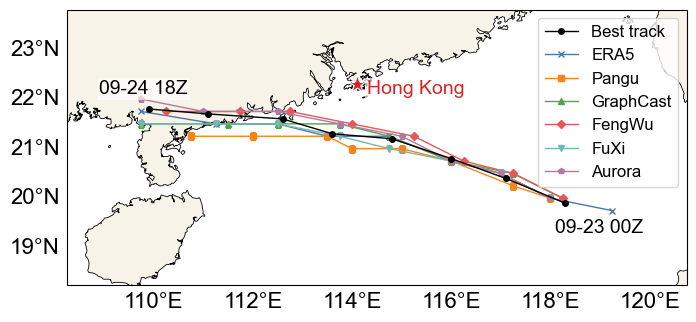

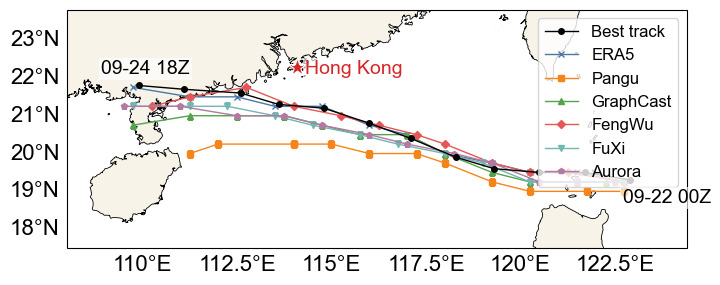

In [26]:
# ----------------------
# Plot 24h / 48h tracks
# ----------------------
plot_track_map(
    '24h',
    cycle_products['24h']['best_track'],
    cycle_products['24h']['forecast_tracks'],
    cycle_products['24h']['extent'],
    output_name='track_forecast_ai_24h.tif',
)

plot_track_map(
    '48h',
    cycle_products['48h']['best_track'],
    cycle_products['48h']['forecast_tracks'],
    cycle_products['48h']['extent'],
    output_name='track_forecast_ai_48h.tif',
)

In [28]:
# ----------------------
# Track error vs Best track (linear interp of best track)
# ----------------------
def haversine_km(lon1, lat1, lon2, lat2):
    # inputs in degrees (can be array-like)
    lon1 = np.deg2rad(np.asarray(lon1))
    lat1 = np.deg2rad(np.asarray(lat1))
    lon2 = np.deg2rad(np.asarray(lon2))
    lat2 = np.deg2rad(np.asarray(lat2))
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c


def interp_best_track(best_df: pd.DataFrame, target_times: pd.DatetimeIndex) -> pd.DataFrame:
    best_df = best_df.sort_values('time')
    t_best = pd.DatetimeIndex(best_df['time']).asi8
    lat_best = best_df['lat'].to_numpy()
    lon_best = best_df['lon'].to_numpy()
    t_target = pd.DatetimeIndex(target_times).asi8

    lat_i = np.interp(t_target, t_best, lat_best)
    lon_i = np.interp(t_target, t_best, lon_best)
    return pd.DataFrame({'valid_time': pd.DatetimeIndex(target_times), 'lat_bt': lat_i, 'lon_bt': lon_i})


def compute_track_error_km(forecast_track: pd.DataFrame, best_df: pd.DataFrame) -> pd.DataFrame:
    # Keep only times within best track range to avoid extrapolation
    t0 = best_df['time'].min()
    t1 = best_df['time'].max()
    ft = forecast_track.loc[forecast_track['valid_time'].between(t0, t1)].copy()
    if ft.empty:
        return pd.DataFrame(columns=['valid_time', 'err_km'])
    bt_i = interp_best_track(best_df, pd.DatetimeIndex(ft['valid_time']))
    err = haversine_km(
        ft['lon'].to_numpy(), ft['lat'].to_numpy(), bt_i['lon_bt'].to_numpy(), bt_i['lat_bt'].to_numpy()
    )
    out = ft[['valid_time']].copy()
    out['err_km'] = err
    return out


error_rows = []
for cycle in ['24h', '48h']:
    best_df = cycle_products[cycle]['best_track']
    for model, track in cycle_products[cycle]['forecast_tracks'].items():
        err_df = compute_track_error_km(track, best_df)
        if err_df.empty:
            continue
        err_df['model'] = model
        err_df['cycle'] = cycle
        error_rows.append(err_df)

track_errors = pd.concat(error_rows, ignore_index=True)
summary = (
    track_errors.groupby(['cycle', 'model'])['err_km']
    .agg(['count', 'mean', 'median', 'max'])
    .sort_values(['cycle', 'mean'])
)
summary

count        mean      median         max
cycle model                                               
24h   era5           7   19.617120   15.982660   43.470155
      aurora         7   22.197053   21.448295   41.623850
      graphcast      7   30.675941   24.504089   66.542710
      fengwu         7   51.354270   48.539599   87.875349
      pangu          7   63.823446   47.980690  125.819375
      fuxi           7  108.696658  110.051499  128.336975
48h   era5          11   15.458583   13.089864   43.470155
      fengwu        11   35.686834   34.918772   71.601848
      aurora        11   38.097056   36.322647   70.308824
      graphcast     11   40.983724   41.101916   87.545121
      pangu         11   97.355862   62.467237  229.033683
      fuxi          11  128.684091  126.281626  144.039930

In [29]:
# Save for later inspection
track_errors.to_csv(PUBLISH_DIR / 'track_errors_ai_vs_best.csv', index=False)
summary.to_csv(PUBLISH_DIR / 'track_errors_ai_vs_best_summary.csv')
print('Saved:', PUBLISH_DIR / 'track_errors_ai_vs_best.csv')
print('Saved:', PUBLISH_DIR / 'track_errors_ai_vs_best_summary.csv')

Saved: publish\track_errors_ai_vs_best.csv
Saved: publish\track_errors_ai_vs_best_summary.csv
